In [3]:
from sklearn.datasets import load_iris
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score

iris = load_iris()
x = iris.data
y = iris.target

pca = PCA(n_components=2)
x_redced = pca.fit_transform(x)

X_train, X_test, y_train, y_test = train_test_split(x_redced, y, test_size=0.2, random_state=42)

In [4]:
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, y_train)

y_pred = knn.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print(f"準確性:{accuracy:.2f}")
print(f"準確性:{accuracy:.2f}")

準確性:1.00
準確性:1.00


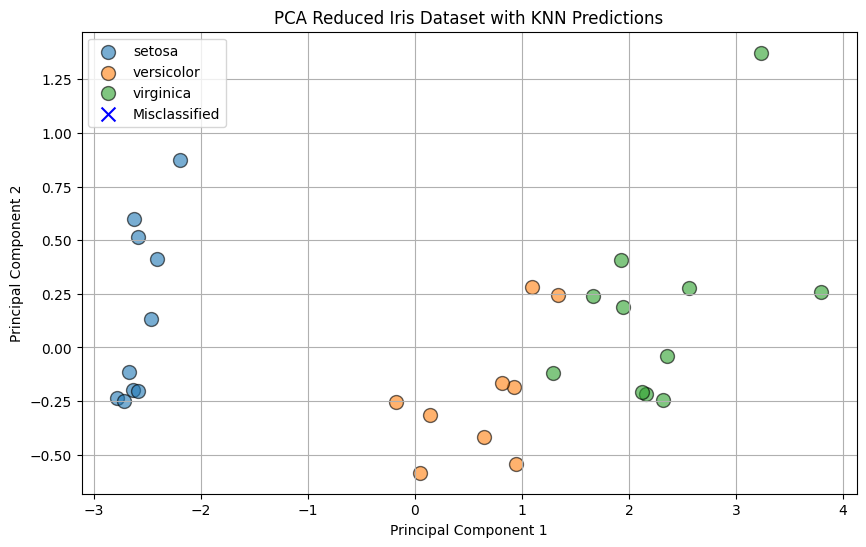

In [5]:
plt.figure(figsize=(10, 6))

for class_value in [0,1,2]:
    subset = X_test[y_test == class_value]
    plt.scatter(subset[:, 0],subset[:,1],label=iris.target_names[class_value], s=100, edgecolors='black', alpha=0.6)

misclassified = X_test[y_test != y_pred]
plt.scatter(misclassified[:, 0], misclassified[:,1], color='blue', marker='x', s=100, label='Misclassified')

plt.title('PCA Reduced Iris Dataset with KNN Predictions')
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()
plt.grid(True)
plt.show()

K=1，準確性:0.97
K=2，準確性:0.97
K=3，準確性:1.00
K=4，準確性:1.00
K=5，準確性:1.00
K=6，準確性:1.00
K=7，準確性:1.00
K=8，準確性:1.00
K=9，準確性:1.00
K=10，準確性:0.97
K=11，準確性:1.00
K=12，準確性:0.97
K=13，準確性:0.93
K=14，準確性:0.97
K=15，準確性:0.97
K=16，準確性:0.97
K=17，準確性:1.00
K=18，準確性:1.00
K=19，準確性:1.00
K=20，準確性:1.00
K=21，準確性:1.00
K=22，準確性:1.00
K=23，準確性:1.00
K=24，準確性:0.97
K=25，準確性:0.97
K=26，準確性:0.97
K=27，準確性:0.97
K=28，準確性:0.97
K=29，準確性:1.00
K=30，準確性:0.97
K=31，準確性:1.00
K=32，準確性:1.00
K=33，準確性:1.00
K=34，準確性:1.00
K=35，準確性:1.00
K=36，準確性:1.00
K=37，準確性:0.97
K=38，準確性:0.97
K=39，準確性:0.97
K=40，準確性:0.93
K=41，準確性:0.93
K=42，準確性:0.93
K=43，準確性:0.93
K=44，準確性:0.93
K=45，準確性:0.93
K=46，準確性:0.93
K=47，準確性:0.93
K=48，準確性:0.93
K=49，準確性:0.93
K=50，準確性:0.93
K=51，準確性:0.93
K=52，準確性:0.93
K=53，準確性:0.93
K=54，準確性:0.93
K=55，準確性:0.93
K=56，準確性:0.93
K=57，準確性:0.93
K=58，準確性:0.97
K=59，準確性:0.97
K=60，準確性:0.97
K=61，準確性:0.93
K=62，準確性:0.97
K=63，準確性:0.97
K=64，準確性:0.97
K=65，準確性:0.97
K=66，準確性:0.97
K=67，準確性:0.93
K=68，準確性:0.97
K=69，準確性:0.93
K=70，準確性:0.97
K=71，準確性:0.97
K=72，準確性:0.97
K

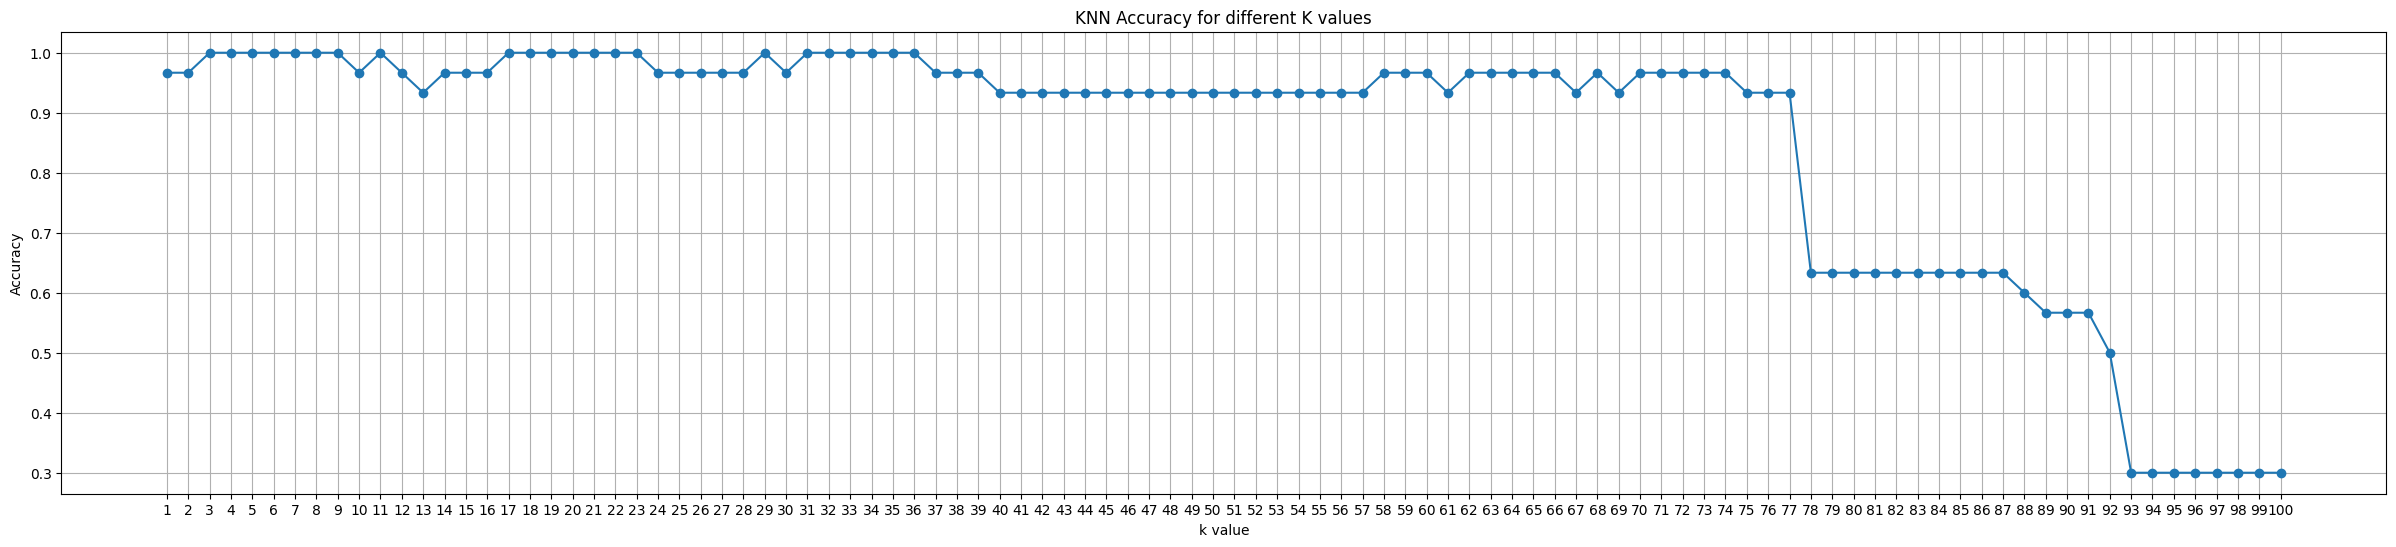

In [6]:

accuracies =[]
for k in range(1,101):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    accuracy = accuracy_score(y_test,y_pred)
    accuracies.append(accuracy)
    print(f"K={k}，準確性:{accuracy:.2f}")

plt.figure(figsize=(30,6))
plt.plot(range(1,101),accuracies, marker='o', linestyle='-')
plt.title('KNN Accuracy for different K values')
plt.xlabel('k value')
plt.ylabel('Accuracy')
plt.xticks(range(1,101))
plt.grid(True)
plt.show()

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

data= load_iris()
x = iris.data
y = iris.target

pca = PCA(n_components=2)
x_pca = pca.fit_transform(x)

X_train, X_test, y_train, y_test = train_test_split(x_redced, y, test_size=0.2, random_state=42)

In [14]:
distances = np.sqrt(-2 * X_test.dot(X_train.T) + np.sum(X_train**2, axis=1) + np.sum(X_test**2, axis=1)[:, np.newaxis])

k = 3
predictions = []

for distance in distances:
    k_indices = np.argsort(distance)[:k]
    k_nearest_labels = y_train[k_indices]
    most_common = np.bincount(k_nearest_labels).argmax()
    predictions.append(most_common)

accuracy = accuracy_score(y_test, predictions)
print(f"Accuracy:{accuracy:.4f}")

Accuracy:1.0000


In [10]:
#homework 1
import numpy as np
test_x = np.array([[5.0,3.2,1.5,0.1]])
transformed_test_x = pca.transform(test_x)
print(transformed_test_x)


[[-2.64506939  0.02490077]]


In [18]:
#homework 2
distance_to_train = np.sqrt(-2 * transformed_test_x.dot(X_train.T) + np.sum(X_train**2, axis=1) + np.sum(transformed_test_x**2, axis=1)[:, np.newaxis])

k_indices = np.argsort(distance_to_train[0])[:k]
k_nearest_labels = y_train[k_indices]
predicted_label = np.bincount(k_nearest_labels).argmax()

print(f"The predicted label for test_x is: {data.target_names[predicted_label]}")

The predicted label for test_x is: setosa
